In [1]:
import os
from azure.ai.textanalytics import TextAnalyticsClient
from azure.core.credentials import AzureKeyCredential

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

message = "By choosing a bike over a car, I’m reducing my environmental footprint. Cycling promotes eco-friendly transportation, and I’m proud to be part of that movement.."

Stabilirea sentimentului mesajului folosind client Azure

In [2]:
key = os.environ["TEXT_KEY"]
endpoint = os.environ["TEXT_ENDPOINT"]

client = TextAnalyticsClient(endpoint=endpoint, credential=AzureKeyCredential(key))
documents = ["By choosing a bike over a car, I’m reducing my environmental footprint. Cycling promotes eco-friendly transportation, and I’m proud to be part of that movement."]

response = client.analyze_sentiment(documents=documents)[0]
print(f"Sentiment Azure: {response.sentiment}")

Sentiment Azure: positive


Extragere caracteristici din texte

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\paulf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\paulf\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\paulf\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean(text):
    text = str(text).lower()

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    
    words = text.split()
    
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

df = pd.read_csv('data/reviews_mixed.csv')

df['CleanText'] = df['Text'].apply(clean)
y = df['Sentiment'].apply(lambda x: 1 if str(x).strip().lower() == 'positive' else 0).values

Dimensiuni BoW:   (207, 500)
Dimensiuni TF-IDF: (207, 500)
Dimensiuni LSA:    (207, 100)


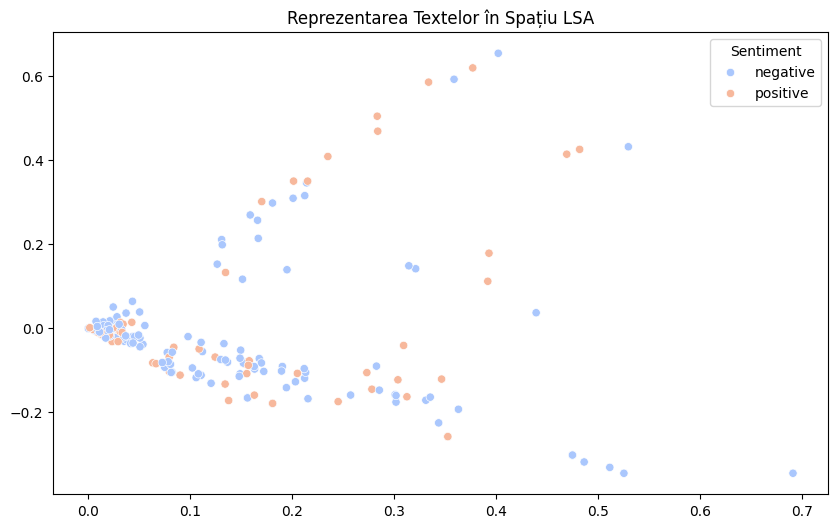

In [5]:
# A. Bag of Words
bow_vec = CountVectorizer(max_features=500)
X_bow = bow_vec.fit_transform(df['CleanText']).toarray()

# B. TF-IDF
tfidf_vec = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_tfidf = tfidf_vec.fit_transform(df['CleanText']).toarray()

# C. LSA
lsa = TruncatedSVD(n_components=100, random_state=42)
X_lsa = lsa.fit_transform(X_tfidf)

print(f"Dimensiuni BoW:   {X_bow.shape}")
print(f"Dimensiuni TF-IDF: {X_tfidf.shape}")
print(f"Dimensiuni LSA:    {X_lsa.shape}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_lsa[:, 0], y=X_lsa[:, 1], hue=df['Sentiment'], palette='coolwarm')
plt.title('Reprezentarea Textelor în Spațiu LSA')
plt.show()

Antrenare ANN (Tool + Manual)


Acuratețe Model TOOL (Scikit-Learn): 78.57%
Acuratețe Model MANUAL:             78.57%


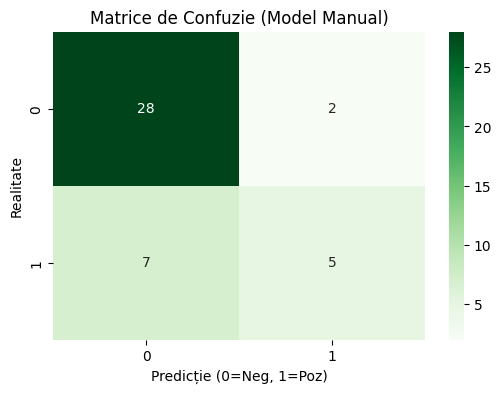

In [6]:
class ManualANN:
    def __init__(self, input_size, hidden_size, output_size=1, learning_rate=0.01):
        self.lr = learning_rate
        self.W1 = np.random.randn(input_size, hidden_size) * 0.1
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.1
        self.b2 = np.zeros((1, output_size))

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

    def _derivata_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self._sigmoid(self.z1)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self._sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        dz2 = output - y 
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        dz1 = np.dot(dz2, self.W2.T) * self._derivata_sigmoid(self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y, epoci=1500):
        for _ in range(epoci):
            y_pred = self.forward(X)
            self.backward(X, y, y_pred)

    def predict(self, X):
        y_pred = self.forward(X)
        return (y_pred >= 0.5).astype(int).flatten()

X_train, X_test, y_train, y_test = train_test_split(X_lsa, y, test_size=0.2, random_state=42)

mlp_tool = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_tool.fit(X_train, y_train)
acc_tool = accuracy_score(y_test, mlp_tool.predict(X_test))

manual_nn = ManualANN(input_size=100, hidden_size=64, learning_rate=0.1)
manual_nn.fit(X_train, y_train, epoci=3000)
acc_manual = accuracy_score(y_test, manual_nn.predict(X_test))

print("\n" + "="*40)
print(f"Acuratețe Model TOOL (Scikit-Learn): {acc_tool*100:.2f}%")
print(f"Acuratețe Model MANUAL:             {acc_manual*100:.2f}%")
print("="*40)

cm = confusion_matrix(y_test, manual_nn.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confuzie (Model Manual)')
plt.xlabel('Predicție (0=Neg, 1=Poz)')
plt.ylabel('Realitate')
plt.show()

Predictie sentiment mesaj (Tool + Manual)

In [7]:
test_msg = message
test_cleaned = clean(test_msg)
test_tfidf = tfidf_vec.transform([test_cleaned])
test_lsa = lsa.transform(test_tfidf)

print(f"Predicție Tool: {'Positive' if mlp_tool.predict(test_lsa)[0] == 1 else 'Negative'}")
print(f"Predicție Manual: {'Positive' if manual_nn.predict(test_lsa)[0] == 1 else 'Negative'}")

Predicție Tool: Negative
Predicție Manual: Negative
